# **Regresión Logística**

## ¿Qué es la Regresión Logística?

A pesar del nombre, la **regresión logística no es un algoritmo de regresión**,  
es un algoritmo de **clasificación binaria**: predice si algo pertenece a la clase 0 o a la clase 1.

### ¿Por qué no usamos regresión lineal para clasificar?

La regresión lineal predice valores continuos (ej: 3.7, -1.2, 9.4).  
Para clasificación necesitamos **probabilidades entre 0 y 1**.

La solución: aplicar la **función sigmoide** a la salida lineal:

$$
\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{donde} \quad z = w \cdot x + b
$$

La sigmoide "aplasta" cualquier valor real al rango (0, 1):

- $z \to +\infty \quad \Rightarrow \quad \sigma(z) \to 1$
- $z = 0 \quad \Rightarrow \quad \sigma(z) = 0.5$
- $z \to -\infty \quad \Rightarrow \quad \sigma(z) \to 0$

### La predicción final

$$
\hat{y} =
\begin{cases}
1 & \text{si } \sigma(z) \geq 0.5 \\
0 & \text{si } \sigma(z) < 0.5
\end{cases}
$$

## ¿Cómo aprende?

En regresión lineal usábamos **MSE**.  
Aquí usamos **Binary Cross-Entropy** (también llamada Log Loss), que penaliza mucho más los errores con alta confianza:

$$
\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]
$$

Y los gradientes son sorprendentemente simples:

$$
\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} x_i (\hat{p}_i - y_i)
$$

$$
\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{p}_i - y_i)
$$

## Dataset

Usaremos dos datasets progresivos:

1. **Horas de estudio → Aprueba/Suspende**  
   (1 feature, fácil de visualizar)

2. **Tumor benigno/maligno**  
   (con 2 features, para ver la frontera de decisión en 2D)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# 1. La función Sigmoide

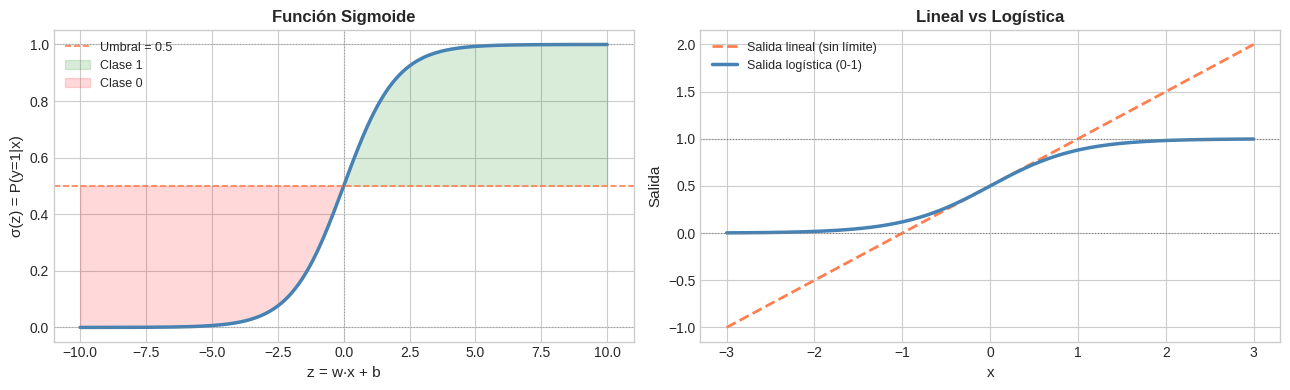

Propiedades de la sigmoide:
  σ(-10) = 0.000045  → casi 0
  σ(0)   = 0.500000  → exactamente 0.5
  σ(10)  = 0.999955  → casi 1


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)
sigma = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Sigmoide ---
ax = axes[0]
ax.plot(z, sigma, color='steelblue', linewidth=2.5)
ax.axhline(0.5, color='coral',  linewidth=1.2, linestyle='--', label='Umbral = 0.5')
ax.axhline(1.0, color='gray',   linewidth=0.8, linestyle=':',  alpha=0.6)
ax.axhline(0.0, color='gray',   linewidth=0.8, linestyle=':',  alpha=0.6)
ax.axvline(0,   color='gray',   linewidth=0.8, linestyle=':',  alpha=0.6)
ax.fill_between(z, sigma, 0.5, where=(sigma >= 0.5), alpha=0.15, color='green', label='Clase 1')
ax.fill_between(z, sigma, 0.5, where=(sigma <  0.5), alpha=0.15, color='red',   label='Clase 0')
ax.set_xlabel('z = w·x + b', fontsize=11)
ax.set_ylabel('σ(z) = P(y=1|x)', fontsize=11)
ax.set_title('Función Sigmoide', fontweight='bold')
ax.legend(fontsize=9)

# --- Comparativa lineal vs logística ---
ax = axes[1]
x_vis = np.linspace(-3, 3, 300)
y_lin = 0.5 * x_vis + 0.5        # salida lineal (puede salir de [0,1])
y_log = sigmoid(2 * x_vis)        # salida logística (siempre en [0,1])
ax.plot(x_vis, y_lin, color='coral',     linewidth=2, linestyle='--', label='Salida lineal (sin límite)')
ax.plot(x_vis, y_log, color='steelblue', linewidth=2.5,               label='Salida logística (0-1)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axhline(1, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('x', fontsize=11); ax.set_ylabel('Salida', fontsize=11)
ax.set_title('Lineal vs Logística', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

# Verificar propiedades
print("Propiedades de la sigmoide:")
print(f"  σ(-10) = {sigmoid(-10):.6f}  → casi 0")
print(f"  σ(0)   = {sigmoid(0):.6f}  → exactamente 0.5")
print(f"  σ(10)  = {sigmoid(10):.6f}  → casi 1")


## 2. Dataset 1 — Horas de estudio → Aprueba (1) / Suspende (0)

Dataset simple con 1 feature para entender cada pieza del algoritmo
antes de añadir más dimensiones

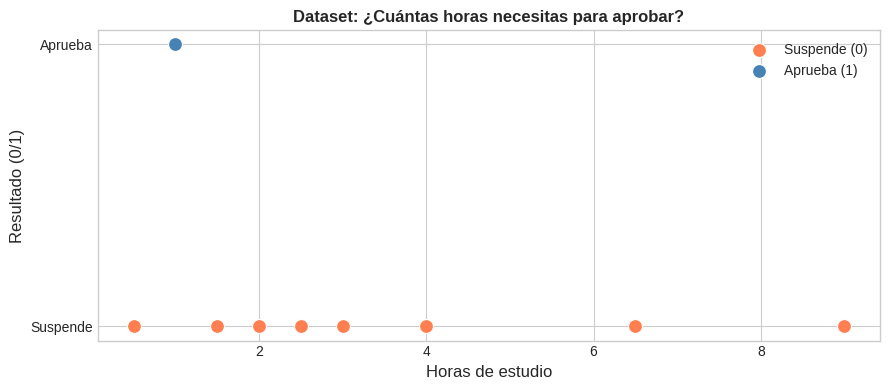

Total muestras : 20
Aprueba (1)    : 12
Suspende (0)   : 8


In [3]:
hours   = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
                    5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0])
pass_or_not = np.array([0,   0,   0,   0,   0,   0,   1,   0,   1,   1,
                    1,   1,   0,   1,   1,   1,   1,   1,   1,   1  ])

# Añadir algo de ruido
np.random.seed(7)
flip_idx = np.random.choice(len(pass_or_not), size=2, replace=False)
pass_or_not[flip_idx] = 1 - pass_or_not[flip_idx]

# Visualización
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(hours[pass_or_not==0], pass_or_not[pass_or_not==0],
           color='coral',     s=100, edgecolors='white', linewidths=0.8,
           zorder=3, label='Suspende (0)')
ax.scatter(pass_or_not[pass_or_not==1], pass_or_not[pass_or_not==1],
           color='steelblue', s=100, edgecolors='white', linewidths=0.8,
           zorder=3, label='Aprueba (1)')
ax.set_xlabel('Horas de estudio', fontsize=12)
ax.set_ylabel('Resultado (0/1)',  fontsize=12)
ax.set_title('Dataset: ¿Cuántas horas necesitas para aprobar?', fontweight='bold')
ax.set_yticks([0, 1]); ax.set_yticklabels(['Suspende', 'Aprueba'])
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print(f"Total muestras : {len(hours)}")
print(f"Aprueba (1)    : {pass_or_not.sum()}")
print(f"Suspende (0)   : {(1-pass_or_not).sum()}")

## 3. Parte 1 — Implementación paso a paso


In [4]:
def sigmoid(z):
    """Función de activación: convierte z en probabilidad."""
    return 1 / (1 + np.exp(-z))

def predict_probabilites(x, w, b):
    """P(y=1|x) = σ(w·x + b)"""
    return sigmoid(w * x + b)

def predict_class(x, w, b, threshold=0.5):
    """Clase predicha: 1 si P >= umbral, 0 si no."""
    return (predict_probabilites(x, w, b) >= threshold).astype(int)

def binary_cross_entropy(y_real, y_prob):
    """
    Log Loss = -1/n · Σ [y·log(p) + (1-y)·log(1-p)]
    """
    p  = np.clip(y_prob, 1e-15, 1 - 1e-15)
    return -np.mean(y_real * np.log(p) + (1 - y_real) * np.log(1 - p))

def calculate_gradients(x, y_real, y_prob):
    """
    dL/dw = 1/n · Σ xᵢ(pᵢ - yᵢ)
    dL/db = 1/n · Σ (pᵢ - yᵢ)
    """
    n     = len(y_real)
    error = y_prob - y_real
    dw    = (1 / n) * np.sum(x * error)
    db    = (1 / n) * np.sum(error)
    return dw, db

# Estado inicial
w, b = 0.0, 0.0
p0   = predict_probabilites(hours, w, b)
print(f"Estado inicial → w={w}, b={b}")
print(f"Probabilidades iniciales: todas = {p0[0]:.2f}  (sin información)")
print(f"Log Loss inicial: {binary_cross_entropy(pass_or_not, p0):.4f}")


Estado inicial → w=0.0, b=0.0
Probabilidades iniciales: todas = 0.50  (sin información)
Log Loss inicial: 0.6931


# Entrenamiento con Gradient Descent

Los gradientes de Binary Cross-Entropy tienen una forma muy limpia:
el error es simplemente `(p - y)`, igual que en regresión lineal.
Esto no es casualidad — es una propiedad de la función sigmoide.

In [8]:
learning_rate  = 0.1
epochs         = 5000
historial_loss = []

w, b = 0.0, 0.0

for epoch in range(epochs):
    p  = predict_probabilites(hours, w, b)
    loss = binary_cross_entropy(pass_or_not, p)
    dw, db = calculate_gradients(hours, pass_or_not, p)

    w -= learning_rate * dw
    b -= learning_rate * db

    historial_loss.append(loss)

    if epoch % 400 == 0:
        acc = np.mean(predict_probabilites(hours, w, b) == pass_or_not)
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Acc: {acc:.2%} | w: {w:.4f} | b: {b:.4f}")

print(f"\n Entrenamiento finalizado")
print(f"   w = {w:.4f} | b = {b:.4f}")
print(f"   Loss final  : {historial_loss[-1]:.4f}")
print(f"   Accuracy    : {np.mean(predict_class(hours, w, b) == pass_or_not):.2%}")


Epoch    0 | Loss: 0.6931 | Acc: 0.00% | w: 0.1175 | b: 0.0100
Epoch  400 | Loss: 0.5601 | Acc: 0.00% | w: 0.3425 | b: -1.2467
Epoch  800 | Loss: 0.5589 | Acc: 0.00% | w: 0.3745 | b: -1.4411
Epoch 1200 | Loss: 0.5588 | Acc: 0.00% | w: 0.3802 | b: -1.4757
Epoch 1600 | Loss: 0.5588 | Acc: 0.00% | w: 0.3813 | b: -1.4820
Epoch 2000 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4832
Epoch 2400 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834
Epoch 2800 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834
Epoch 3200 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834
Epoch 3600 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834
Epoch 4000 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834
Epoch 4400 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834
Epoch 4800 | Loss: 0.5588 | Acc: 0.00% | w: 0.3815 | b: -1.4834

 Entrenamiento finalizado
   w = 0.3815 | b = -1.4834
   Loss final  : 0.5588
   Accuracy    : 75.00%


##PLOT📊

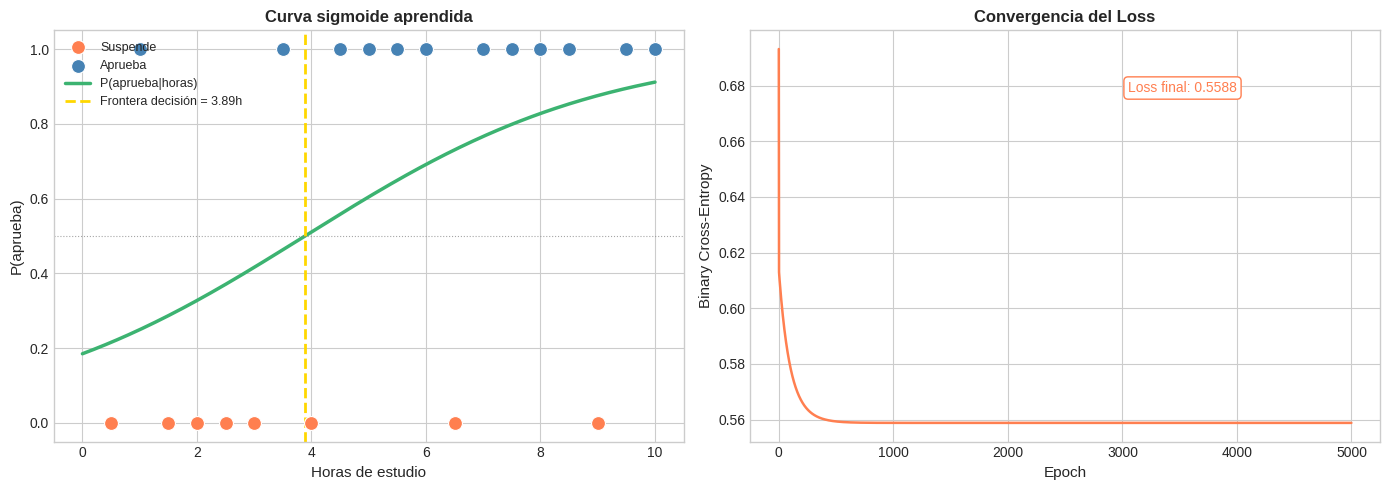


📍 Frontera de decisión: 3.89 horas
   Con menos de 3.9h → predice Suspende
   Con más  de  3.9h → predice Aprueba


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva sigmoide aprendida ---
ax = axes[0]
x_line  = np.linspace(0, 10, 300)
p_line  = predict_probabilites(x_line, w, b)
umbral_x = -b / w  # punto donde p = 0.5

ax.scatter(hours[pass_or_not==0], pass_or_not[pass_or_not==0],
           color='coral', s=100, edgecolors='white', linewidths=0.8, zorder=3, label='Suspende')
ax.scatter(hours[pass_or_not==1], pass_or_not[pass_or_not==1],
           color='steelblue', s=100, edgecolors='white', linewidths=0.8, zorder=3, label='Aprueba')
ax.plot(x_line, p_line, color='mediumseagreen', linewidth=2.5, label='P(aprueba|horas)')
ax.axvline(umbral_x, color='gold', linewidth=2, linestyle='--',
           label=f'Frontera decisión = {umbral_x:.2f}h')
ax.axhline(0.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
ax.set_xlabel('Horas de estudio', fontsize=11)
ax.set_ylabel('P(aprueba)', fontsize=11)
ax.set_title('Curva sigmoide aprendida', fontweight='bold')
ax.legend(fontsize=9)

# --- Curva de loss ---
ax = axes[1]
ax.plot(historial_loss, color='coral', linewidth=1.8)
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Binary Cross-Entropy', fontsize=11)
ax.set_title('Convergencia del Loss', fontweight='bold')
ax.text(0.6, 0.85, f'Loss final: {historial_loss[-1]:.4f}',
        transform=ax.transAxes, fontsize=10, color='coral',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='coral'))

plt.tight_layout(); plt.show()

print(f"\n Frontera de decisión: {umbral_x:.2f} horas")
print(f"   Con menos de {umbral_x:.1f}h → predice Suspende")
print(f"   Con más  de  {umbral_x:.1f}h → predice Aprueba")

# 3. Parte 2 — Clase RegresionLogistica

Misma interfaz que antes: `.fit()` / `.predict()` / `.predict_proba()` / `.score()`
Añadimos además `.predict_proba()` para obtener las probabilidades,
no solo la clase — igual que scikit-learn.

In [15]:
class RegresionLogistica:
    def __init__(self, learning_rate=0.1, epochs=2000, threshold=0.5, verbose=400):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.threshold  = threshold
        self.verbose = verbose
        self.w_ = None
        self.b_ = None
        self.historial_loss_ = []

    def fit(self, x, y):
        self.w_ = 0.0
        self.b_ = 0.0
        self.historial_loss_ = []
        n = len(y)

        for epoch in range(self.epochs):
            p = self._sigmoid(self.w_ * x + self.b_)
            loss = self._bce(y, p)
            error = p - y #predicted vs real
            dw = (1 / n) * np.sum(x * error)
            db = (1 / n) * np.sum(error)

            self.w_ -= self.learning_rate * dw
            self.b_ -= self.learning_rate * db
            self.historial_loss_.append(loss)

            if self.verbose and epoch % self.verbose == 0:
                accuracy = np.mean((p >= self.threshold).astype(int) == y)
                print(f"  Epoch {epoch:5d} | Loss: {loss:.4f} | Acc: {accuracy:.2%}")

        acc_final = self.score(x, y)
        print(f"\n Entrenado | w={self.w_:.4f} | b={self.b_:.4f}")
        print(f"   Loss final: {self.historial_loss_[-1]:.4f} | Acc: {acc_final:.2%}")
        return self

    def predict_prob(self, x):
        """Devuelve P(y=1|x) para cada muestra."""
        self._check_fitted()
        return self._sigmoid(self.w_ * x + self.b_)

    def predict(self, x):
        """Devuelve clase predicha (0 o 1)."""
        return (self.predict_prob(x) >= self.threshold).astype(int)

    def score(self, x, y):
        """Accuracy — % de predicciones correctas."""
        self._check_fitted()
        return np.mean(self.predict(x) == y)

    def plot(self, x, y, titulo="Regresión Logística"):
        self._check_fitted()
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        x_line = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
        p_line = self.predict_prob(x_line)
        frontera = -self.b_ / self.w_

        ax = axes[0]
        ax.scatter(x[y==0], y[y==0], color='coral', s=90,
                   edgecolors='white', linewidths=0.8, zorder=3, label='Clase 0')
        ax.scatter(x[y==1], y[y==1], color='steelblue', s=90,
                   edgecolors='white', linewidths=0.8, zorder=3, label='Clase 1')
        ax.plot(x_line, p_line, color='mediumseagreen', linewidth=2.5,
                label='P(clase=1|x)')
        ax.axvline(frontera, color='gold', linewidth=2, linestyle='--',
                   label=f'Frontera = {frontera:.2f}')
        ax.axhline(0.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
        ax.set_xlabel('x'); ax.set_ylabel('Probabilidad')
        ax.set_title(titulo, fontweight='bold')
        ax.legend(fontsize=9)

        ax = axes[1]
        ax.plot(self.historial_loss_, color='coral', linewidth=1.8)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy')
        ax.set_title('Convergencia del Loss', fontweight='bold')

        plt.tight_layout(); plt.show()

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _bce(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def _check_fitted(self):
        if self.w_ is None:
            raise RuntimeError("Modelo no entrenado. Llama a .fit() primero.")



  Epoch     0 | Loss: 0.6931 | Acc: 60.00%
  Epoch   500 | Loss: 0.5593 | Acc: 75.00%
  Epoch  1000 | Loss: 0.5588 | Acc: 75.00%
  Epoch  1500 | Loss: 0.5588 | Acc: 75.00%

 Entrenado | w=0.3815 | b=-1.4832
   Loss final: 0.5588 | Acc: 75.00%


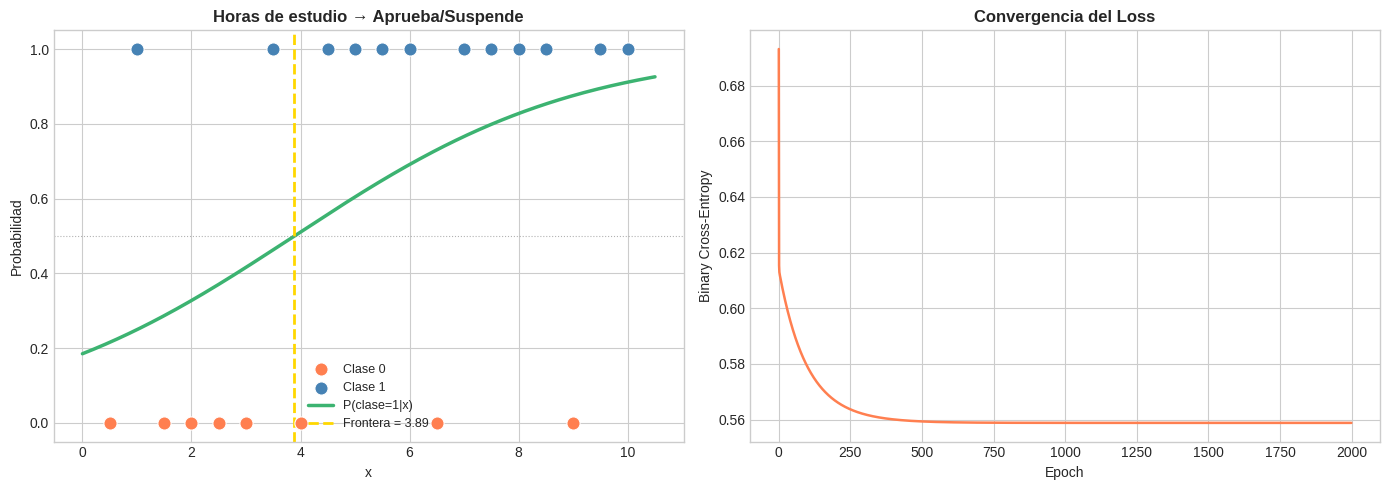


Predicciones individuales:
   Hours | Prob: (pass) |   Prediction
  ------------------------------------
     2.0 |       0.8276 |         Pass
     4.0 |       0.8276 |         Pass
     5.0 |       0.8276 |         Pass
     6.0 |       0.8276 |         Pass
     8.0 |       0.8276 |         Pass


In [16]:
# --- Usar la clase ---
logistic_regression = RegresionLogistica(learning_rate=0.1, epochs=2000, verbose=500)
logistic_regression.fit(hours, pass_or_not)
logistic_regression.plot(hours, pass_or_not, titulo="Horas de estudio → Aprueba/Suspende")

# Predicciones con probabilidad
print("\nPredicciones individuales:")
print(f"  {'Hours':>6} | {'Prob: (pass)':>12} | {'Prediction':>12}")
print(f"  {'-'*36}")
for h in [2, 4, 5, 6, 8]:
    prediction = logistic_regression.predict_prob(np.array([h]))[0]
    pred = "Pass" if p >= 0.5 else "Fail"
    print(f"  {h:>6.1f} | {p:>12.4f} | {pred:>12}")

# 4. Dataset 2 — Diagnóstico de tumor (2 features)

Con dos features podemos visualizar la **frontera de decisión** en 2D,
que es lo que realmente separa las dos clases en el espacio de features.

Features:
- `tamaño_tumor` — tamaño del tumor (mm)
- `edad_paciente` — edad del paciente

Target:
- `0` → benigno
- `1` → maligno

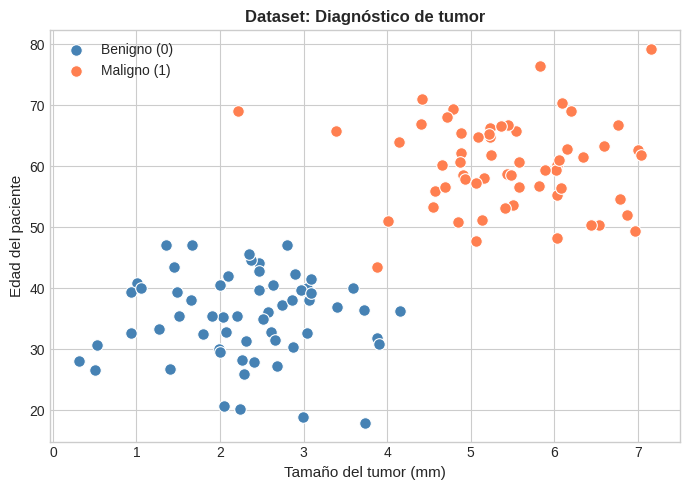

In [17]:
#Dataset sintético de tumores
n = 120

# Clase 0 (benigno): tumores pequeños, pacientes jóvenes
X0 = np.random.multivariate_normal([2.5, 35], [[0.8, 0.3],[0.3, 40]], n//2)

# Clase 1 (maligno): tumores grandes, pacientes mayores
X1 = np.random.multivariate_normal([5.5, 60], [[0.9, 0.3],[0.3, 50]], n//2)

X_tumor = np.vstack([X0, X1])
y_tumor = np.hstack([np.zeros(n//2), np.ones(n//2)])

# Shuffle
idx = np.random.permutation(n)
X_tumor, y_tumor = X_tumor[idx], y_tumor[idx]

# Visualización inicial
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_tumor[y_tumor==0, 0], X_tumor[y_tumor==0, 1],
           color='steelblue', s=70, edgecolors='white', linewidths=0.8,
           zorder=3, label='Benigno (0)')
ax.scatter(X_tumor[y_tumor==1, 0], X_tumor[y_tumor==1, 1],
           color='coral', s=70, edgecolors='white', linewidths=0.8,
           zorder=3, label='Maligno (1)')
ax.set_xlabel('Tamaño del tumor (mm)', fontsize=11)
ax.set_ylabel('Edad del paciente',      fontsize=11)
ax.set_title('Dataset: Diagnóstico de tumor', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()


In [33]:
class RegresionLogisticaMulti:
    """
    Regresión Logística para múltiples features.
    Ahora w_ es un vector de shape (n_features,).
    """
    def __init__(self, learning_rate=0.1, epochs=3000, umbral=0.5, verbose=500):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.umbral = umbral
        self.verbose = verbose
        self.w_ = None
        self.b_ = None
        self.historial_loss_ = []

    def fit(self, X, y):
        n, p = X.shape
        self.w_ = np.zeros(p)
        self.b_ = 0.0
        self.historial_loss_ = []

        for epoch in range(self.epochs):
            z = X @ self.w_ + self.b_
            probability = self._sigmoid(z)
            loss  = self._bce(y, probability)
            error = probability - y

            dw = (1 / n) * X.T @ error
            db = (1 / n) * np.sum(error)

            self.w_ -= self.learning_rate * dw
            self.b_ -= self.learning_rate * db
            self.historial_loss_.append(loss)

            if self.verbose and epoch % self.verbose == 0:
                acc = np.mean((probability >= self.umbral).astype(int) == y)
                print(f"  Epoch {epoch:5d} | Loss: {loss:.4f} | Acc: {acc:.2%}")

        acc_f = self.score(X, y)
        print(f"\n Entrenado | Loss: {self.historial_loss_[-1]:.4f} | Acc: {acc_f:.2%}")
        return self

    def predict_prob(self, X):
        self._check_fitted()
        return self._sigmoid(X @ self.w_ + self.b_)

    def predict(self, X):
        return (self.predict_prob(X) >= self.umbral).astype(int)

    def score(self, X, y):
        self._check_fitted()
        return np.mean(self.predict(X) == y)

    def plot_frontier(self, X, y, feature_names=None):
        """Visualiza la frontera de decisión en 2D (solo para 2 features)."""
        self._check_fitted()
        if X.shape[1] != 2:
            raise ValueError("plot_frontera solo funciona con 2 features.")

        fn = feature_names or ['Feature 1', 'Feature 2']
        h  = 0.05
        x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
        y_min, y_max = X[:, 1].min()-2,   X[:, 1].max()+2

        xx, yy   = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
        X_grid   = np.c_[xx.ravel(), yy.ravel()]
        Z  = self.predict_prob(X_grid).reshape(xx.shape)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Frontera de decisión ---
        ax = axes[0]
        ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.4)
        ax.contour( xx, yy, Z, levels=[0.5], colors='gold', linewidths=2.5, linestyles='--')
        ax.scatter(X[y==0, 0], X[y==0, 1], color='steelblue', s=60, edgecolors='white', linewidths=0.8, zorder=3, label='Benigno (0)')
        ax.scatter(X[y==1, 0], X[y==1, 1], color='coral',     s=60, edgecolors='white', linewidths=0.8, zorder=3, label='Maligno (1)')
        ax.set_xlabel(fn[0], fontsize=11); ax.set_ylabel(fn[1], fontsize=11)
        ax.set_title('Frontera de decisión', fontweight='bold')
        ax.legend(fontsize=9)

        from matplotlib.lines import Line2D
        ax.add_artist(Line2D([0],[0], color='gold', linewidth=2, linestyle='--', label='Frontera (p=0.5)'))

        # --- Loss ---
        ax = axes[1]
        ax.plot(self.historial_loss_, color='coral', linewidth=1.8)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy')
        ax.set_title('Convergencia del Loss', fontweight='bold')

        plt.tight_layout(); plt.show()

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _bce(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def _check_fitted(self):
        if self.w_ is None:
            raise RuntimeError("Modelo no entrenado. Llama a .fit() primero.")

  Epoch     0 | Loss: 0.6931 | Acc: 50.00%
  Epoch   600 | Loss: 0.0382 | Acc: 99.17%
  Epoch  1200 | Loss: 0.0273 | Acc: 99.17%
  Epoch  1800 | Loss: 0.0230 | Acc: 99.17%
  Epoch  2400 | Loss: 0.0206 | Acc: 99.17%

 Entrenado | Loss: 0.0189 | Acc: 99.17%


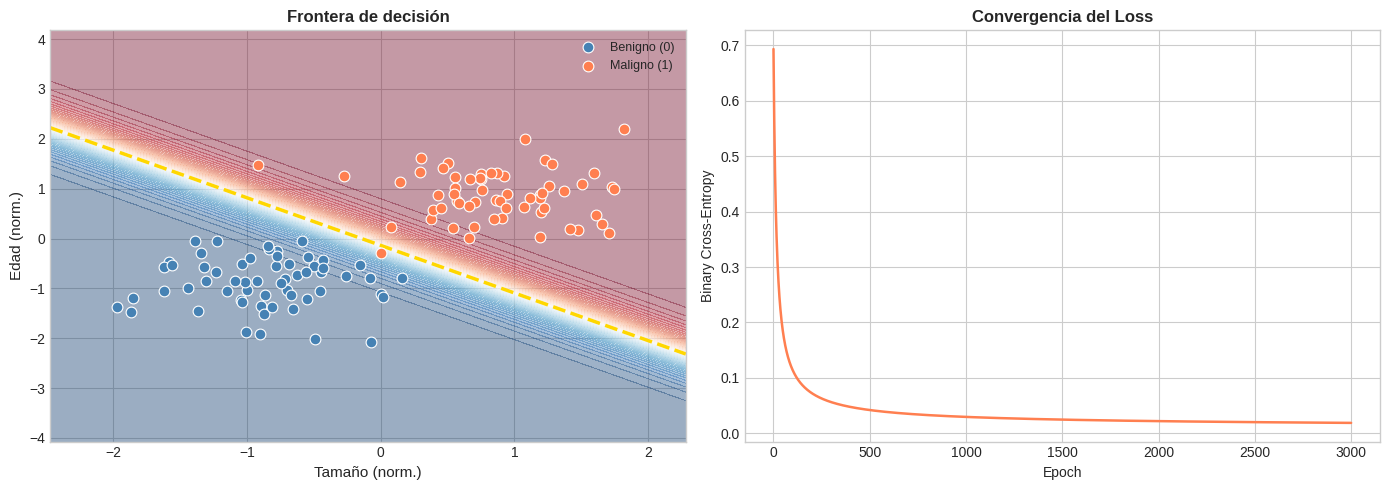

In [22]:
# Normalizar features (importante para GD con múltiples features)
X_mean  = X_tumor.mean(axis=0)
X_std   = X_tumor.std(axis=0)
X_norm  = (X_tumor - X_mean) / X_std

logistic_regression_multi = RegresionLogisticaMulti(learning_rate=0.1, epochs=3000, verbose=600)
logistic_regression_multi.fit(X_norm, y_tumor)
logistic_regression_multi.plot_frontier(X_norm, y_tumor,
                           feature_names=['Tamaño (norm.)', 'Edad (norm.)'])

# 5. Métricas de clasificación

En clasificación las métricas son distintas a las de regresión.
La **accuracy** sola puede engañar mucho (dataset desbalanceado).
Necesitamos métricas que capturen los 4 posibles resultados:

```
                    PREDICHO
                  0         1
REAL    0    TN (✅)   FP (❌)   ← Especificidad
        1    FN (❌)   TP (✅)   ← Sensibilidad / Recall
```

| Métrica | Fórmula | Cuándo importa |
|---|---|---|
| **Accuracy** | (TP+TN) / total | Dataset balanceado |
| **Precision** | TP / (TP+FP) | Coste alto de falsos positivos |
| **Recall** | TP / (TP+FN) | Coste alto de falsos negativos (medicina) |
| **F1-Score** | 2·P·R / (P+R) | Balance entre precision y recall |
| **Log Loss** | Binary Cross-Entropy | Calidad de las probabilidades |
| **AUC-ROC** | Área bajo la curva ROC | Separabilidad general del modelo |

In [25]:

def matrix_confusion(y_real, y_pred):
    TP = np.sum((y_pred == 1) & (y_real == 1))
    TN = np.sum((y_pred == 0) & (y_real == 0))
    FP = np.sum((y_pred == 1) & (y_real == 0))
    FN = np.sum((y_pred == 0) & (y_real == 1))
    return TP, TN, FP, FN

def calculate_classification_metrics(y_real, y_pred, y_proba, name="Modelo"):
    TP, TN, FP, FN = matrix_confusion(y_real, y_pred)
    n = len(y_real)
    acc = (TP + TN) / n
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    # Log Loss
    p_clip  = np.clip(y_proba, 1e-15, 1 - 1e-15)
    logloss = -np.mean(y_real * np.log(p_clip) + (1 - y_real) * np.log(1 - p_clip))

    print(f"\n{'='*48}")
    print(f"📊 Métricas de clasificación — {name}")
    print(f"{'='*48}")
    print(f"Matriz de confusión:")
    print(f"TP={TP:3d}  FP={FP:3d}")
    print(f"FN={FN:3d}  TN={TN:3d}")
    print(f"{'─'*36}")
    print(f"Accuracy = {acc:.4f}   ({acc*100:.1f}% correctas)")
    print(f"Precision = {prec:.4f}   (de los que predice 1, {prec*100:.1f}% son 1)")
    print(f"Recall = {recall:.4f}   (detecta el {recall*100:.1f}% de los 1 reales)")
    print(f"F1-Score = {f1:.4f}   (balance precision/recall)")
    print(f"Specificity = {spec:.4f}   (detecta el {spec*100:.1f}% de los 0 reales)")
    print(f"Log Loss  = {logloss:.4f}")
    print(f"{'='*48}")

    return {"TP":TP,"TN":TN,"FP":FP,"FN":FN,
            "accuracy":acc,"precision":prec,"recall":recall,
            "f1":f1,"specificity":spec,"log_loss":logloss}


**RESULTADOS**

In [26]:
y_pred_simple  = logistic_regression.predict(hours)
y_proba_simple = logistic_regression.predict_prob(hours)
m1 = calculate_classification_metrics(pass_or_not, y_pred_simple, y_proba_simple, "Horas→Aprueba")

# Métricas del modelo multivariable
y_pred_multi  = logistic_regression_multi.predict(X_norm)
y_proba_multi = logistic_regression_multi.predict_prob(X_norm)
m2 = calculate_classification_metrics(y_tumor, y_pred_multi, y_proba_multi, "Tumor (2 features)")


📊 Métricas de clasificación — Horas→Aprueba
Matriz de confusión:
TP= 10  FP=  3
FN=  2  TN=  5
────────────────────────────────────
Accuracy = 0.7500   (75.0% correctas)
Precision = 0.7692   (de los que predice 1, 76.9% son 1)
Recall = 0.8333   (detecta el 83.3% de los 1 reales)
F1-Score = 0.8000   (balance precision/recall)
Specificity = 0.6250   (detecta el 62.5% de los 0 reales)
Log Loss  = 0.5588

📊 Métricas de clasificación — Tumor (2 features)
Matriz de confusión:
TP= 59  FP=  0
FN=  1  TN= 60
────────────────────────────────────
Accuracy = 0.9917   (99.2% correctas)
Precision = 1.0000   (de los que predice 1, 100.0% son 1)
Recall = 0.9833   (detecta el 98.3% de los 1 reales)
F1-Score = 0.9916   (balance precision/recall)
Specificity = 1.0000   (detecta el 100.0% de los 0 reales)
Log Loss  = 0.0189


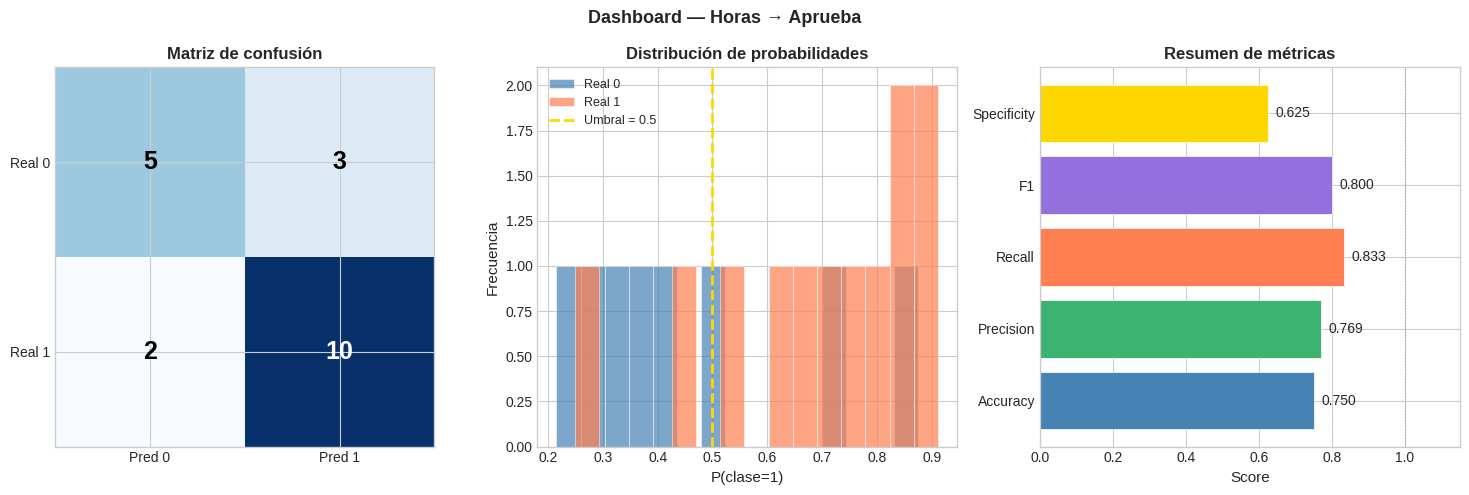

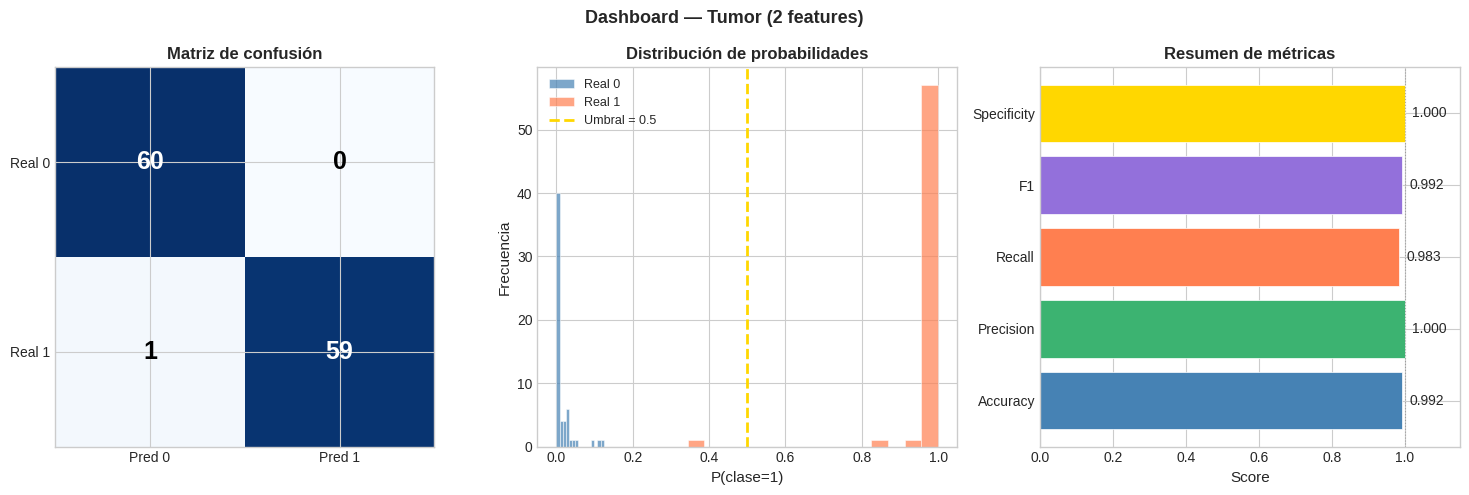

In [28]:
def plot_dashboard(y_real, y_pred, y_proba, metricas, titulo=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Dashboard — {titulo}', fontsize=13, fontweight='bold')

    # --- 1. Matriz de confusión ---
    ax = axes[0]
    cm = np.array([[metricas['TN'], metricas['FP']],
                    [metricas['FN'], metricas['TP']]])
    im  = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1'])
    ax.set_yticklabels(['Real 0','Real 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=18, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title('Matriz de confusión', fontweight='bold')

    # --- 2. Distribución de probabilidades ---
    ax = axes[1]
    ax.hist(y_proba[y_real==0], bins=15, alpha=0.7,
            color='steelblue', edgecolor='white', linewidth=0.5, label='Real 0')
    ax.hist(y_proba[y_real==1], bins=15, alpha=0.7,
            color='coral',     edgecolor='white', linewidth=0.5, label='Real 1')
    ax.axvline(0.5, color='gold', linewidth=2, linestyle='--', label='Umbral = 0.5')
    ax.set_xlabel('P(clase=1)', fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title('Distribución de probabilidades', fontweight='bold')
    ax.legend(fontsize=9)

    # --- 3. Barras de métricas ---
    ax = axes[2]
    names = ['Accuracy','Precision','Recall','F1','Specificity']
    values = [metricas['accuracy'], metricas['precision'],
               metricas['recall'],   metricas['f1'], metricas['specificity']]
    colors = ['steelblue','mediumseagreen','coral','mediumpurple','gold']
    bars = ax.barh(names, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlim(0, 1.15)
    for bar, val in zip(bars, values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='500')
    ax.set_xlabel('Score', fontsize=11)
    ax.set_title('Resumen de métricas', fontweight='bold')
    ax.axvline(1.0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)

    plt.tight_layout(); plt.show()

plot_dashboard(pass_or_not, y_pred_simple, y_proba_simple, m1, "Horas → Aprueba")
plot_dashboard(y_tumor, y_pred_multi,  y_proba_multi,  m2, "Tumor (2 features)")


# 6. Con scikit-learn

scikit-learn usa por defecto el solver `lbfgs` — un algoritmo de
optimización de segundo orden (usa información de curvatura, no solo gradiente).
Es más eficiente que nuestro Gradient Descent para datasets pequeños.

La interfaz es la misma: `.fit()` / `.predict()` / `.predict_proba()` / `.score()`

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score)
from sklearn.preprocessing import StandardScaler

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_tumor, y_tumor, test_size=0.25, random_state=42, stratify=y_tumor
)

# Normalizar (con StandardScaler — aprende media/std del train)
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# --- Entrenar modelo de Scikit-learn ---
sklearn_logistic_model = LogisticRegression(random_state=42)
sklearn_logistic_model.fit(X_train_scaled, y_train)

# Evaluación de Scikit-learn
y_pred_sklearn  = sklearn_logistic_model.predict(X_test_scaled)
y_proba_sklearn = sklearn_logistic_model.predict_proba(X_test_scaled)[:, 1]

print("📊 Reporte completo Scikit-learn:")
print(classification_report(y_test, y_pred_sklearn,
                             target_names=['Benigno','Maligno']))
print(f"AUC-ROC (Scikit-learn): {roc_auc_score(y_test, y_proba_sklearn):.4f}")

# --- Entrenar nuestro modelo ---
logistic_regression_multi = RegresionLogisticaMulti(learning_rate=0.1, epochs=3000, verbose=600)
logistic_regression_multi.fit(X_train_scaled, y_train)

# Evaluación de nuestro modelo
lrm_y_pred  = logistic_regression_multi.predict(X_test_scaled)
lrm_y_prob = logistic_regression_multi.predict_prob(X_test_scaled)

print("\n📊 Reporte completo Nuestro Modelo:")
lrm_metrics = calculate_classification_metrics(y_test, lrm_y_pred, lrm_y_prob, "Nuestro Modelo (2 features)")
print(f"AUC-ROC (Nuestro Modelo): {roc_auc_score(y_test, lrm_y_prob):.4f}")

# Comparativa de coeficientes
print(f"\n Coeficientes aprendidos:")
print(f"  sklearn      → w={sklearn_logistic_model.coef_[0]}, b={sklearn_logistic_model.intercept_[0]:.4f}")
print(f"  Nuestro clase → w={logistic_regression_multi.w_}, b={logistic_regression_multi.b_:.4f}")

📊 Reporte completo Scikit-learn:
              precision    recall  f1-score   support

     Benigno       0.94      1.00      0.97        15
     Maligno       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

AUC-ROC (Scikit-learn): 1.0000
  Epoch     0 | Loss: 0.6931 | Acc: 50.00%
  Epoch   600 | Loss: 0.0305 | Acc: 100.00%
  Epoch  1200 | Loss: 0.0184 | Acc: 100.00%
  Epoch  1800 | Loss: 0.0137 | Acc: 100.00%
  Epoch  2400 | Loss: 0.0111 | Acc: 100.00%

 Entrenado | Loss: 0.0094 | Acc: 100.00%

📊 Reporte completo Nuestro Modelo:

📊 Métricas de clasificación — Nuestro Modelo (2 features)
Matriz de confusión:
TP= 14  FP=  0
FN=  1  TN= 15
────────────────────────────────────
Accuracy = 0.9667   (96.7% correctas)
Precision = 1.0000   (de los que predice 1, 100.0% son 1)
Recall = 0.9333   (detecta el 93.3% de los 1 reales)
F1-Score = 0.965

## Curva ROC y AUC

La curva ROC muestra el trade-off entre:
- **TPR (Recall)** — % de positivos detectados
- **FPR**          — % de negativos mal clasificados como positivos

Un modelo perfecto tiene AUC = 1.0. Un modelo aleatorio tiene AUC = 0.5.

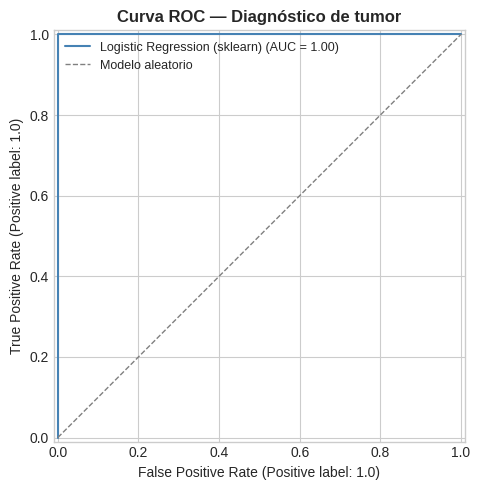

In [40]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(sklearn_logistic_model, X_test_scaled, y_test,
                                name='Logistic Regression (sklearn)',
                                color='steelblue', ax=ax)
ax.plot([0,1],[0,1], linestyle='--', color='gray', linewidth=1, label='Modelo aleatorio')
ax.set_title('Curva ROC — Diagnóstico de tumor', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

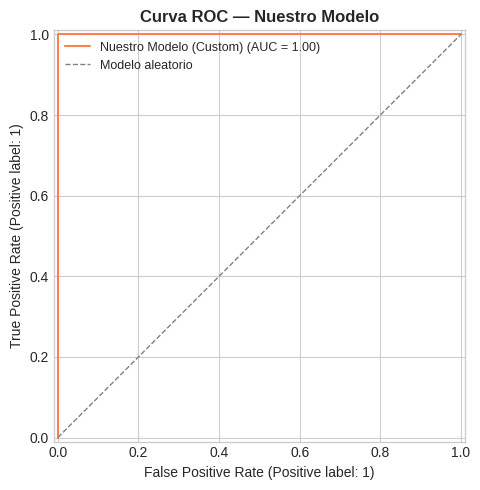

In [41]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, lrm_y_prob,
                                 name='Nuestro Modelo (Custom)',
                                 color='coral', ax=ax)
ax.plot([0,1],[0,1], linestyle='--', color='gray', linewidth=1, label='Modelo aleatorio')
ax.set_title('Curva ROC — Nuestro Modelo', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()